# ML2 Final MLOps Workflow — Required Experiments Version

This notebook is the final clean workflow for the anonymous multi-class classification assignment.

It focuses on the required MLOps deliverable:

1. Run a small, representative set of meaningful experiments.
2. Track all experiments with MLflow.
3. Log consistent parameters and metrics for every run.
4. Use a strong validation strategy that does not depend on Kaggle public feedback.
5. Save the selected model and preprocessing steps together as an MLflow artifact.
6. Generate the final submission file using the selected model.

Important: this notebook intentionally uses a **focused set of representative experiments** instead of showing every exploratory run from development. The broader search was useful during development, but this final version is designed to be readable, reproducible, and suitable for submission.

## 1. Problem Definition

The task is an anonymous multi-class classification problem. The training file contains `ID`, 21 anonymous features `f1` to `f21`, and the target class. The test file contains `ID` and the same 21 features, but no target.

Because the features are anonymous, no domain-specific feature assumptions are used. The workflow relies on data inspection, validation, model comparison, and MLOps tracking.

The final output must be a CSV file with exactly two columns:

```text
ID,target
```

In [1]:
from pathlib import Path
import os
import json
import time
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import joblib

try:
    import mlflow
    import mlflow.sklearn
    from mlflow.tracking import MlflowClient
except Exception as e:
    mlflow = None
    MlflowClient = None
    print("MLflow is not available. Install it with: pip install mlflow")
    print("Import error:", e)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Project Paths

The notebook assumes that these files are in the same folder as the notebook:

- `train_data.csv`
- `test_data.csv`
- `sample_submission.csv`

All generated outputs are stored in `results_required_mlops/`.

In [2]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
RESULTS_DIR = PROJECT_DIR / "results_required_mlops"
REPORTS_DIR = RESULTS_DIR / "reports"
SUBMISSIONS_DIR = RESULTS_DIR / "submissions"
ARTIFACTS_DIR = RESULTS_DIR / "artifacts"
MLFLOW_ARTIFACTS_DIR = RESULTS_DIR / "mlflow_artifacts"

for d in [RESULTS_DIR, REPORTS_DIR, SUBMISSIONS_DIR, ARTIFACTS_DIR, MLFLOW_ARTIFACTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Train exists:", TRAIN_PATH.exists())
print("Test exists:", TEST_PATH.exists())
print("Sample submission exists:", SAMPLE_PATH.exists())

Project directory: c:\Users\ASUS\Desktop\ML_2
Results directory: c:\Users\ASUS\Desktop\ML_2\results_required_mlops
Train exists: True
Test exists: True
Sample submission exists: True


## 3. Load Data and Basic Checks

The `ID` column is not used as a training feature. It is kept only for the final submission file.

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

feature_cols = [c for c in train_df.columns if c.startswith("f")]
X = train_df[feature_cols].copy()
y = train_df["target"].copy()
X_test = test_df[feature_cols].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Number of features:", len(feature_cols))
print("Feature columns:", feature_cols)
print("Missing values in train:", int(train_df.isna().sum().sum()))
print("Missing values in test:", int(test_df.isna().sum().sum()))
print("Duplicate train IDs:", int(train_df["ID"].duplicated().sum()))
print("Duplicate test IDs:", int(test_df["ID"].duplicated().sum()))

class_distribution = y.value_counts().sort_index().rename_axis("target").reset_index(name="count")
class_distribution["percentage"] = 100 * class_distribution["count"] / len(y)
class_distribution.to_csv(REPORTS_DIR / "target_distribution.csv", index=False)
class_distribution

Train shape: (3200, 23)
Test shape: (3200, 22)
Number of features: 21
Feature columns: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']
Missing values in train: 0
Missing values in test: 0
Duplicate train IDs: 0
Duplicate test IDs: 0


,target,count,percentage
0,class1,93,2.90625
1,class2,191,5.96875
2,class3,2916,91.12500


## 4. Class Imbalance

The target distribution is highly imbalanced. Therefore, plain accuracy is not sufficient. A model can obtain a high accuracy by mostly predicting the majority class.

For this reason, the main validation metrics are:

- `macro_f1_mean`: treats all classes equally.
- `balanced_accuracy_mean`: averages recall across classes.
- `weighted_f1_mean`: accounts for class support while still using F1.
- `accuracy_mean`: still logged, but not used alone for selection.

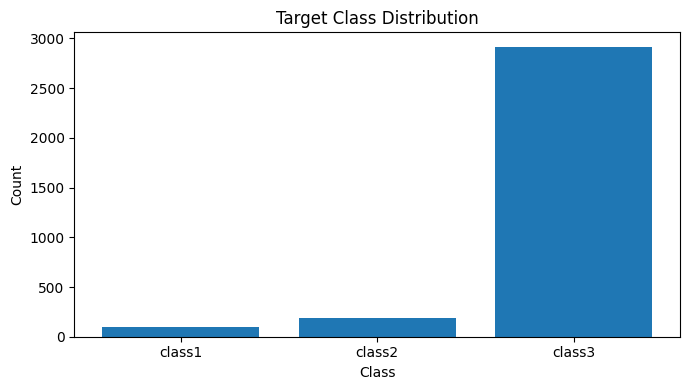

In [4]:
plt.figure(figsize=(7, 4))
plt.bar(class_distribution["target"], class_distribution["count"])
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "target_distribution.png", dpi=160)
plt.show()

## 5. Validation Strategy

A strong validation strategy is more important than chasing the public leaderboard. The public leaderboard may not represent the private leaderboard, so the model is selected primarily by local validation stability.

This notebook uses:

- `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- identical folds for all experiments
- consistent metrics for every run
- a stability-aware selection score

The stability score is:

```text
stability_adjusted_macro_f1 = macro_f1_mean - macro_f1_std
```

This prevents choosing a model only because it achieved a slightly higher mean score while being unstable across folds.

Oversampling, when used, is applied **inside each training fold only**. It is never applied before splitting the data. This avoids validation leakage.

## 6. MLflow Setup

This notebook uses a SQLite MLflow backend. This is more stable on Windows than the old file-based `mlruns` backend.

The experiment name is:

```text
ML2_final_required_experiments
```

The notebook resets previous active runs in this experiment before logging, so the MLflow dashboard remains clean and focused on the required experiments.

In [5]:
EXPERIMENT_NAME = "ML2_final_required_experiments"
RESET_EXISTING_RUNS = True

if mlflow is not None:
    MLFLOW_DB_PATH = RESULTS_DIR / "mlflow.db"
    MLFLOW_TRACKING_URI = "sqlite:///" + MLFLOW_DB_PATH.resolve().as_posix()
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("MLflow tracking URI:", mlflow.get_tracking_uri())
    print("Experiment name:", EXPERIMENT_NAME)

    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

    if RESET_EXISTING_RUNS and experiment is not None:
        existing_runs = mlflow.search_runs(
            experiment_ids=[experiment.experiment_id],
            filter_string="attributes.status != 'DELETED'",
            output_format="pandas"
        )
        for run_id in existing_runs.get("run_id", []):
            try:
                client.delete_run(run_id)
            except Exception:
                pass
        print("Reset active runs in experiment:", len(existing_runs))
else:
    print("MLflow is not installed. The notebook will still create local CSV/HTML reports, but MLflow tracking is required for the assignment.")

2026/07/01 15:55:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/01 15:55:51 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

MLflow tracking URI: sqlite:///C:/Users/ASUS/Desktop/ML_2/results_required_mlops/mlflow.db
Experiment name: ML2_final_required_experiments
Reset active runs in experiment: 0


## 7. Helper Functions

The following functions build pipelines, evaluate models with stratified cross-validation, apply fold-safe random oversampling when required, and log every experiment to MLflow.

In [6]:
def make_pipeline(model, scaler="none"):
    steps = [("imputer", SimpleImputer(strategy="median"))]

    if scaler == "standard":
        steps.append(("scaler", StandardScaler()))
    elif scaler != "none":
        raise ValueError(f"Unsupported scaler: {scaler}")

    steps.append(("model", model))
    return Pipeline(steps)


def random_oversample_training_fold(X_train, y_train, random_state=RANDOM_STATE):
    """Simple fold-safe random oversampling without imblearn.

    This is intentionally applied only to the training fold after the CV split.
    The validation fold is never oversampled.
    """
    tmp = X_train.copy().reset_index(drop=True)
    tmp["target"] = y_train.reset_index(drop=True)

    max_count = tmp["target"].value_counts().max()
    parts = []
    for cls, group in tmp.groupby("target"):
        parts.append(group.sample(max_count, replace=True, random_state=random_state))

    out = pd.concat(parts, axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out[feature_cols], out["target"]


def evaluate_cv(estimator, X, y, sampling="none", n_splits=5, random_state=RANDOM_STATE):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []
    oof_predictions = pd.Series(index=y.index, dtype=object)

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = clone(estimator)

        if sampling == "random_oversampler":
            X_fit, y_fit = random_oversample_training_fold(X_train, y_train, random_state=random_state + fold)
        else:
            X_fit, y_fit = X_train, y_train

        model.fit(X_fit, y_fit)
        valid_pred = model.predict(X_valid)
        train_pred = model.predict(X_train)
        oof_predictions.iloc[valid_idx] = valid_pred

        fold_rows.append({
            "fold": fold,
            "accuracy": accuracy_score(y_valid, valid_pred),
            "balanced_accuracy": balanced_accuracy_score(y_valid, valid_pred),
            "macro_f1": f1_score(y_valid, valid_pred, average="macro"),
            "weighted_f1": f1_score(y_valid, valid_pred, average="weighted"),
            "train_accuracy": accuracy_score(y_train, train_pred),
            "train_macro_f1": f1_score(y_train, train_pred, average="macro"),
        })

    folds_df = pd.DataFrame(fold_rows)

    metrics = {}
    for m in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "train_accuracy", "train_macro_f1"]:
        metrics[f"{m}_mean"] = float(folds_df[m].mean())
        metrics[f"{m}_std"] = float(folds_df[m].std())

    metrics["train_valid_macro_f1_gap"] = metrics["train_macro_f1_mean"] - metrics["macro_f1_mean"]
    metrics["stability_adjusted_macro_f1"] = metrics["macro_f1_mean"] - metrics["macro_f1_std"]

    return metrics, folds_df, oof_predictions


def safe_param(value):
    if value is None:
        return "None"
    if isinstance(value, (str, int, float, bool)):
        return value
    return str(value)

## 8. Representative Experiments

The following experiments were selected from the full development history because each one tests a different idea:

1. Majority-class baseline.
2. Linear model with scaling and class weights.
3. SVM with scaling and class weights.
4. Stable Random Forest with balanced class weights.
5. Random Forest with `balanced_subsample` as an alternative weighting strategy.
6. Gradient Boosting with shallow trees and low learning rate.
7. Fold-safe random oversampling with Logistic Regression.
8. Decision Tree depth 5 to test whether a simple rule-based model can explain the data.

This is intentionally not a random collection of models. Each experiment tests a specific modeling or imbalance-handling assumption.

In [7]:
experiment_specs = [
    {
        "run_name": "01_dummy_majority_baseline",
        "model_name": "DummyClassifier",
        "scaler": "none",
        "sampling": "none",
        "class_weight": "not_applicable",
        "n_estimators": "not_applicable",
        "max_depth": "not_applicable",
        "min_samples_leaf": "not_applicable",
        "learning_rate": "not_applicable",
        "C": "not_applicable",
        "gamma": "not_applicable",
        "model": DummyClassifier(strategy="most_frequent"),
        "why_tested": "Majority-class baseline to expose the weakness of accuracy on imbalanced data.",
        "expected_issue": "High accuracy can be misleading; minority classes are ignored."
    },
    {
        "run_name": "02_logistic_regression_balanced_standard",
        "model_name": "LogisticRegression",
        "scaler": "standard",
        "sampling": "none",
        "class_weight": "balanced",
        "n_estimators": "not_applicable",
        "max_depth": "not_applicable",
        "min_samples_leaf": "not_applicable",
        "learning_rate": "not_applicable",
        "C": 1.0,
        "gamma": "not_applicable",
        "model": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
        "why_tested": "Linear baseline with scaling and class weights.",
        "expected_issue": "May underfit nonlinear feature interactions."
    },
    {
        "run_name": "03_svm_rbf_balanced_standard",
        "model_name": "SVC",
        "scaler": "standard",
        "sampling": "none",
        "class_weight": "balanced",
        "n_estimators": "not_applicable",
        "max_depth": "not_applicable",
        "min_samples_leaf": "not_applicable",
        "learning_rate": "not_applicable",
        "C": 3.0,
        "gamma": "scale",
        "model": SVC(C=3.0, kernel="rbf", gamma="scale", class_weight="balanced", random_state=RANDOM_STATE),
        "why_tested": "Nonlinear margin-based model with scaling and class weights.",
        "expected_issue": "Can be sensitive to scaling and minority-class boundary noise."
    },
    {
        "run_name": "04_random_forest_balanced_n500_final_candidate",
        "model_name": "RandomForestClassifier",
        "scaler": "none",
        "sampling": "none",
        "class_weight": "balanced",
        "n_estimators": 500,
        "max_depth": "None",
        "min_samples_leaf": 1,
        "learning_rate": "not_applicable",
        "C": "not_applicable",
        "gamma": "not_applicable",
        "model": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
        "why_tested": "Main ensemble model; handles nonlinear patterns and uses class weights for imbalance.",
        "expected_issue": "Can overfit if trees memorize noise, so fold stability is monitored."
    },
    {
        "run_name": "05_random_forest_balanced_subsample_n300",
        "model_name": "RandomForestClassifier",
        "scaler": "none",
        "sampling": "none",
        "class_weight": "balanced_subsample",
        "n_estimators": 300,
        "max_depth": "None",
        "min_samples_leaf": 1,
        "learning_rate": "not_applicable",
        "C": "not_applicable",
        "gamma": "not_applicable",
        "model": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1),
        "why_tested": "Tests an alternative class-weighting strategy computed per bootstrap sample.",
        "expected_issue": "May introduce more variance than the stable balanced Random Forest."
    },
    {
        "run_name": "06_gradient_boosting_depth3_lr002",
        "model_name": "GradientBoostingClassifier",
        "scaler": "none",
        "sampling": "none",
        "class_weight": "not_applicable",
        "n_estimators": 300,
        "max_depth": 3,
        "min_samples_leaf": 1,
        "learning_rate": 0.02,
        "C": "not_applicable",
        "gamma": "not_applicable",
        "model": GradientBoostingClassifier(n_estimators=300, learning_rate=0.02, max_depth=3, random_state=RANDOM_STATE),
        "why_tested": "Boosting candidate with shallow trees and low learning rate.",
        "expected_issue": "High mean validation can still be unstable across folds if it overfits difficult boundaries."
    },
    {
        "run_name": "07_random_oversampler_logistic_standard",
        "model_name": "LogisticRegression",
        "scaler": "standard",
        "sampling": "random_oversampler",
        "class_weight": "None",
        "n_estimators": "not_applicable",
        "max_depth": "not_applicable",
        "min_samples_leaf": "not_applicable",
        "learning_rate": "not_applicable",
        "C": 1.0,
        "gamma": "not_applicable",
        "model": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
        "why_tested": "Tests fold-safe oversampling as an alternative to class weights.",
        "expected_issue": "Oversampling can amplify minority-class noise and may not beat class weighting."
    },
    {
        "run_name": "08_decision_tree_depth5_leaf1",
        "model_name": "DecisionTreeClassifier",
        "scaler": "none",
        "sampling": "none",
        "class_weight": "None",
        "n_estimators": "not_applicable",
        "max_depth": 5,
        "min_samples_leaf": 1,
        "learning_rate": "not_applicable",
        "C": "not_applicable",
        "gamma": "not_applicable",
        "model": DecisionTreeClassifier(max_depth=5, min_samples_leaf=1, random_state=RANDOM_STATE),
        "why_tested": "Tests whether a simple rule-based tree is sufficient and interpretable.",
        "expected_issue": "Single trees can be unstable; one split change can strongly alter predictions."
    },
]

pd.DataFrame([{k: v for k, v in s.items() if k != "model"} for s in experiment_specs])

,run_name,model_name,scaler,sampling,class_weight,n_estimators,max_depth,min_samples_leaf,learning_rate,C,gamma,why_tested,expected_issue
0,01_dummy_majority_baseline,DummyClassifier,none,none,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,Majority-class baseline to expose the weakness...,High accuracy can be misleading; minority clas...
1,02_logistic_regression_balanced_standard,LogisticRegression,standard,none,balanced,not_applicable,not_applicable,not_applicable,not_applicable,1.0,not_applicable,Linear baseline with scaling and class weights.,May underfit nonlinear feature interactions.
2,03_svm_rbf_balanced_standard,SVC,standard,none,balanced,not_applicable,not_applicable,not_applicable,not_applicable,3.0,scale,Nonlinear margin-based model with scaling and ...,Can be sensitive to scaling and minority-class...
3,04_random_forest_balanced_n500_final_candidate,RandomForestClassifier,none,none,balanced,500,None,1,not_applicable,not_applicable,not_applicable,Main ensemble model; handles nonlinear pattern...,"Can overfit if trees memorize noise, so fold s..."
4,05_random_forest_balanced_subsample_n300,RandomForestClassifier,none,none,balanced_subsample,300,None,1,not_applicable,not_applicable,not_applicable,Tests an alternative class-weighting strategy ...,May introduce more variance than the stable ba...
5,06_gradient_boosting_depth3_lr002,GradientBoostingClassifier,none,none,not_applicable,300,3,1,0.02,not_applicable,not_applicable,Boosting candidate with shallow trees and low ...,High mean validation can still be unstable acr...
6,07_random_oversampler_logistic_standard,LogisticRegression,standard,random_oversampler,None,not_applicable,not_applicable,not_applicable,not_applicable,1.0,not_applicable,Tests fold-safe oversampling as an alternative...,Oversampling can amplify minority-class noise ...
7,08_decision_tree_depth5_leaf1,DecisionTreeClassifier,none,none,None,not_applicable,5,1,not_applicable,not_applicable,not_applicable,Tests whether a simple rule-based tree is suff...,Single trees can be unstable; one split change...


## 9. Run Experiments and Log to MLflow

Every run logs the same metric names. This is important because inconsistent metric names create unreadable MLflow tables with missing values.

The logged metrics are:

- `accuracy_mean`, `accuracy_std`
- `balanced_accuracy_mean`, `balanced_accuracy_std`
- `macro_f1_mean`, `macro_f1_std`
- `weighted_f1_mean`, `weighted_f1_std`
- `train_valid_macro_f1_gap`
- `stability_adjusted_macro_f1`

In [8]:
all_results = []
oof_predictions_by_run = {}

for spec in experiment_specs:
    run_name = spec["run_name"]
    estimator = make_pipeline(spec["model"], scaler=spec["scaler"])

    print("Running:", run_name)
    metrics, folds_df, oof_pred = evaluate_cv(
        estimator,
        X,
        y,
        sampling=spec["sampling"],
        n_splits=5,
        random_state=RANDOM_STATE,
    )

    fold_path = REPORTS_DIR / f"{run_name}_fold_metrics.csv"
    folds_df.to_csv(fold_path, index=False)
    oof_predictions_by_run[run_name] = oof_pred

    row = {k: v for k, v in spec.items() if k != "model"}
    row.update(metrics)
    row["fold_metrics_file"] = str(fold_path)
    all_results.append(row)

    if mlflow is not None:
        with mlflow.start_run(run_name=run_name):
            mlflow.log_param("run_name", run_name)
            mlflow.log_param("model_name", spec["model_name"])
            mlflow.log_param("scaler", spec["scaler"])
            mlflow.log_param("sampling", spec["sampling"])
            mlflow.log_param("class_weight", spec["class_weight"])
            mlflow.log_param("n_estimators", spec["n_estimators"])
            mlflow.log_param("max_depth", spec["max_depth"])
            mlflow.log_param("min_samples_leaf", spec["min_samples_leaf"])
            mlflow.log_param("learning_rate", spec["learning_rate"])
            mlflow.log_param("C", spec["C"])
            mlflow.log_param("gamma", spec["gamma"])
            mlflow.log_param("cv_strategy", "StratifiedKFold")
            mlflow.log_param("cv_folds", 5)
            mlflow.log_param("random_state", RANDOM_STATE)
            mlflow.log_param("feature_count", len(feature_cols))
            mlflow.log_param("why_tested", spec["why_tested"])
            mlflow.log_param("expected_issue", spec["expected_issue"])

            for metric_name, metric_value in metrics.items():
                mlflow.log_metric(metric_name, float(metric_value))

            mlflow.log_artifact(str(fold_path), artifact_path="fold_metrics")

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("stability_adjusted_macro_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(REPORTS_DIR / "required_experiment_results.csv", index=False)

pd.set_option("display.max_columns", 100)
results_df[[
    "run_name", "model_name", "scaler", "sampling", "class_weight", "n_estimators",
    "max_depth", "learning_rate", "accuracy_mean", "balanced_accuracy_mean",
    "macro_f1_mean", "macro_f1_std", "weighted_f1_mean", "train_valid_macro_f1_gap",
    "stability_adjusted_macro_f1", "expected_issue"
]]

Running: 01_dummy_majority_baseline
Running: 02_logistic_regression_balanced_standard
Running: 03_svm_rbf_balanced_standard
Running: 04_random_forest_balanced_n500_final_candidate
Running: 05_random_forest_balanced_subsample_n300
Running: 06_gradient_boosting_depth3_lr002
Running: 07_random_oversampler_logistic_standard
Running: 08_decision_tree_depth5_leaf1


,run_name,model_name,scaler,sampling,class_weight,n_estimators,max_depth,learning_rate,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,macro_f1_std,weighted_f1_mean,train_valid_macro_f1_gap,stability_adjusted_macro_f1,expected_issue
0,04_random_forest_balanced_n500_final_candidate,RandomForestClassifier,none,none,balanced,500,None,not_applicable,0.996250,0.993594,0.985702,0.003508,0.996292,1.429819e-02,0.982194,"Can overfit if trees memorize noise, so fold s..."
1,08_decision_tree_depth5_leaf1,DecisionTreeClassifier,none,none,None,not_applicable,5,not_applicable,0.998125,0.992330,0.991668,0.012275,0.998130,5.564403e-03,0.979393,Single trees can be unstable; one split change...
2,05_random_forest_balanced_subsample_n300,RandomForestClassifier,none,none,balanced_subsample,300,None,not_applicable,0.996250,0.990004,0.983877,0.005346,0.996292,1.612284e-02,0.978531,May introduce more variance than the stable ba...
3,06_gradient_boosting_depth3_lr002,GradientBoostingClassifier,none,none,not_applicable,300,3,0.02,0.996875,0.991873,0.987421,0.013084,0.996917,1.257863e-02,0.974337,High mean validation can still be unstable acr...
4,02_logistic_regression_balanced_standard,LogisticRegression,standard,none,balanced,not_applicable,not_applicable,not_applicable,0.971875,0.960560,0.896040,0.021086,0.973531,2.199891e-02,0.874954,May underfit nonlinear feature interactions.
5,07_random_oversampler_logistic_standard,LogisticRegression,standard,random_oversampler,None,not_applicable,not_applicable,not_applicable,0.961875,0.940239,0.868190,0.034789,0.964568,2.843571e-02,0.833401,Oversampling can amplify minority-class noise ...
6,03_svm_rbf_balanced_standard,SVC,standard,none,balanced,not_applicable,not_applicable,not_applicable,0.946250,0.880480,0.815826,0.055769,0.950669,8.399874e-02,0.760057,Can be sensitive to scaling and minority-class...
7,01_dummy_majority_baseline,DummyClassifier,none,none,not_applicable,not_applicable,not_applicable,not_applicable,0.911250,0.333333,0.317855,0.000127,0.868936,3.495078e-08,0.317727,High accuracy can be misleading; minority clas...


## 10. Why the Final Model Is Selected Without Relying on Kaggle

The final selection is not based only on public leaderboard feedback. The public leaderboard may not reflect the private leaderboard, so the model must be selected using local validation evidence.

The selection logic is:

1. Reject the Dummy baseline because it ignores minority classes.
2. Reject models with weak macro F1 or balanced accuracy.
3. Be careful with models that have a high mean score but large fold-to-fold variance.
4. Prefer a model with a strong stability-adjusted macro F1 score.
5. Prefer an ensemble model over a single tree when both are competitive, because ensemble averaging reduces sensitivity to individual splits.

For this reason, the stable Random Forest is selected as the final model. It is not always the highest raw validation mean, but it provides a strong and stable compromise between macro F1, balanced accuracy, fold stability, and robustness.

In [9]:
# Add a human-readable decision column.
def decision_reason(row):
    name = row["run_name"]
    if "dummy" in name:
        return "Rejected: majority-class baseline; poor macro F1 and balanced accuracy."
    if "logistic_regression_balanced" in name:
        return "Rejected: useful linear baseline but underfits nonlinear patterns."
    if "svm" in name:
        return "Rejected: lower macro F1 and higher fold instability than tree ensembles."
    if "random_oversampler" in name:
        return "Rejected: oversampling did not outperform class-weighted Random Forest."
    if "balanced_subsample" in name:
        return "Rejected: close to final RF but slightly lower stability-adjusted score."
    if "gradient_boosting" in name:
        return "Rejected: strong mean score, but higher fold variance than final RF."
    if "decision_tree" in name:
        return "Rejected: high local mean but single-tree model is less robust and more split-sensitive."
    if "random_forest_balanced_n500" in name:
        return "Selected: best balance of strong validation, low variance, ensemble robustness, and reproducibility."
    return "Reviewed."

results_df["decision"] = results_df.apply(decision_reason, axis=1)
results_df.to_csv(REPORTS_DIR / "required_experiment_results_with_decisions.csv", index=False)

results_df[[
    "run_name", "model_name", "macro_f1_mean", "macro_f1_std",
    "balanced_accuracy_mean", "train_valid_macro_f1_gap",
    "stability_adjusted_macro_f1", "decision"
]]

,run_name,model_name,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,train_valid_macro_f1_gap,stability_adjusted_macro_f1,decision
0,04_random_forest_balanced_n500_final_candidate,RandomForestClassifier,0.985702,0.003508,0.993594,1.429819e-02,0.982194,"Selected: best balance of strong validation, l..."
1,08_decision_tree_depth5_leaf1,DecisionTreeClassifier,0.991668,0.012275,0.992330,5.564403e-03,0.979393,Rejected: high local mean but single-tree mode...
2,05_random_forest_balanced_subsample_n300,RandomForestClassifier,0.983877,0.005346,0.990004,1.612284e-02,0.978531,Rejected: close to final RF but slightly lower...
3,06_gradient_boosting_depth3_lr002,GradientBoostingClassifier,0.987421,0.013084,0.991873,1.257863e-02,0.974337,"Rejected: strong mean score, but higher fold v..."
4,02_logistic_regression_balanced_standard,LogisticRegression,0.896040,0.021086,0.960560,2.199891e-02,0.874954,Rejected: useful linear baseline but underfits...
5,07_random_oversampler_logistic_standard,LogisticRegression,0.868190,0.034789,0.940239,2.843571e-02,0.833401,Rejected: oversampling did not outperform clas...
6,03_svm_rbf_balanced_standard,SVC,0.815826,0.055769,0.880480,8.399874e-02,0.760057,Rejected: lower macro F1 and higher fold insta...
7,01_dummy_majority_baseline,DummyClassifier,0.317855,0.000127,0.333333,3.495078e-08,0.317727,Rejected: majority-class baseline; poor macro ...


## 11. Experiment Comparison Plots

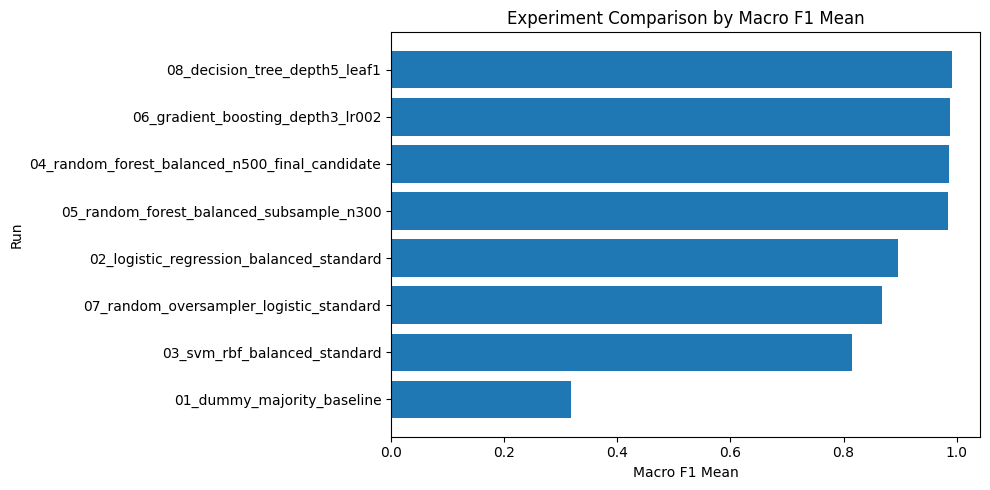

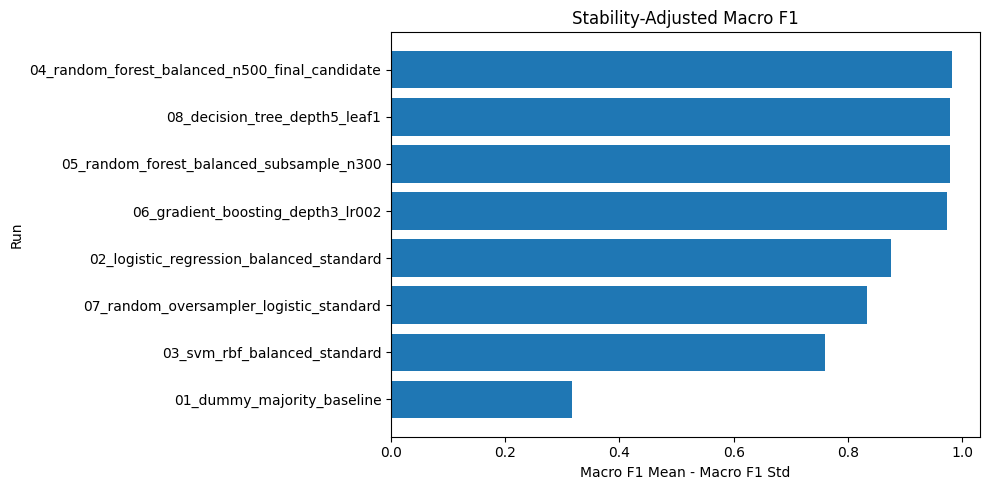

In [10]:
plot_df = results_df.sort_values("macro_f1_mean", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["run_name"], plot_df["macro_f1_mean"])
plt.title("Experiment Comparison by Macro F1 Mean")
plt.xlabel("Macro F1 Mean")
plt.ylabel("Run")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "experiment_macro_f1_comparison.png", dpi=160)
plt.show()

plot_df2 = results_df.sort_values("stability_adjusted_macro_f1", ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(plot_df2["run_name"], plot_df2["stability_adjusted_macro_f1"])
plt.title("Stability-Adjusted Macro F1")
plt.xlabel("Macro F1 Mean - Macro F1 Std")
plt.ylabel("Run")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "experiment_stability_adjusted_macro_f1.png", dpi=160)
plt.show()

## 12. Clean MLflow Dashboard Export

The official MLflow UI should be used for the screenshot. If the browser UI has a rendering issue, this notebook also exports a clean HTML dashboard directly from the MLflow tracking database.

Use the MLflow UI experiment:

```text
ML2_final_required_experiments
```

Recommended MLflow UI columns:

- `params.model_name`
- `params.scaler`
- `params.sampling`
- `params.class_weight`
- `params.n_estimators`
- `params.max_depth`
- `params.learning_rate`
- `metrics.accuracy_mean`
- `metrics.balanced_accuracy_mean`
- `metrics.macro_f1_mean`
- `metrics.weighted_f1_mean`
- `metrics.stability_adjusted_macro_f1`

In [11]:
# Export a clean comparison dashboard from MLflow runs.
if mlflow is not None:
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], output_format="pandas")

    cols = [
        "tags.mlflow.runName",
        "params.model_name", "params.scaler", "params.sampling", "params.class_weight",
        "params.n_estimators", "params.max_depth", "params.min_samples_leaf",
        "params.learning_rate", "params.C", "params.gamma",
        "metrics.accuracy_mean", "metrics.balanced_accuracy_mean", "metrics.macro_f1_mean",
        "metrics.macro_f1_std", "metrics.weighted_f1_mean",
        "metrics.train_valid_macro_f1_gap", "metrics.stability_adjusted_macro_f1",
        "status", "start_time"
    ]
    available_cols = [c for c in cols if c in runs.columns]
    clean_runs = runs[available_cols].copy()

    rename_map = {
        "tags.mlflow.runName": "run_name",
        "params.model_name": "model_name",
        "params.scaler": "scaler",
        "params.sampling": "sampling",
        "params.class_weight": "class_weight",
        "params.n_estimators": "n_estimators",
        "params.max_depth": "max_depth",
        "params.min_samples_leaf": "min_samples_leaf",
        "params.learning_rate": "learning_rate",
        "params.C": "C",
        "params.gamma": "gamma",
        "metrics.accuracy_mean": "accuracy_mean",
        "metrics.balanced_accuracy_mean": "balanced_accuracy_mean",
        "metrics.macro_f1_mean": "macro_f1_mean",
        "metrics.macro_f1_std": "macro_f1_std",
        "metrics.weighted_f1_mean": "weighted_f1_mean",
        "metrics.train_valid_macro_f1_gap": "train_valid_macro_f1_gap",
        "metrics.stability_adjusted_macro_f1": "stability_adjusted_macro_f1",
    }
    clean_runs = clean_runs.rename(columns=rename_map)
    clean_runs = clean_runs.sort_values("stability_adjusted_macro_f1", ascending=False, na_position="last")

    clean_csv = REPORTS_DIR / "mlflow_required_experiments_dashboard.csv"
    clean_html = REPORTS_DIR / "mlflow_required_experiments_dashboard.html"
    clean_runs.to_csv(clean_csv, index=False)

    html = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>MLflow Required Experiments Dashboard</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 32px; background: #f8fafc; color: #111827; }}
            h1 {{ margin-bottom: 8px; }}
            p {{ color: #4b5563; }}
            table {{ border-collapse: collapse; width: 100%; background: white; font-size: 13px; box-shadow: 0 1px 4px rgba(0,0,0,0.08); }}
            th, td {{ border: 1px solid #e5e7eb; padding: 8px; text-align: left; white-space: nowrap; }}
            th {{ background: #e5e7eb; color: #111827; position: sticky; top: 0; }}
            tr:nth-child(even) {{ background: #f9fafb; }}
            .note {{ background: #eef2ff; border-left: 4px solid #6366f1; padding: 12px; margin: 18px 0; }}
        </style>
    </head>
    <body>
        <h1>MLflow Required Experiments Dashboard</h1>
        <p>This dashboard is exported from MLflow runs using <code>mlflow.search_runs</code>.</p>
        <div class="note">
            Every run logs the same core metrics: accuracy_mean, balanced_accuracy_mean, macro_f1_mean, weighted_f1_mean, and stability_adjusted_macro_f1.
        </div>
        <p><b>Tracking URI:</b> {mlflow.get_tracking_uri()}</p>
        {clean_runs.to_html(index=False)}
    </body>
    </html>
    """
    clean_html.write_text(html, encoding="utf-8")

    print("Created MLflow dashboard files:")
    print(clean_csv)
    print(clean_html)
    display(clean_runs)
else:
    print("MLflow not available; dashboard export skipped.")

Created MLflow dashboard files:
c:\Users\ASUS\Desktop\ML_2\results_required_mlops\reports\mlflow_required_experiments_dashboard.csv
c:\Users\ASUS\Desktop\ML_2\results_required_mlops\reports\mlflow_required_experiments_dashboard.html


,run_name,model_name,scaler,sampling,class_weight,n_estimators,max_depth,min_samples_leaf,learning_rate,C,gamma,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,macro_f1_std,weighted_f1_mean,train_valid_macro_f1_gap,stability_adjusted_macro_f1,status,start_time
4,04_random_forest_balanced_n500_final_candidate,RandomForestClassifier,none,none,balanced,500,None,1,not_applicable,not_applicable,not_applicable,0.996250,0.993594,0.985702,0.003508,0.996292,1.429819e-02,0.982194,FINISHED,2026-07-01 12:56:03.612000+00:00
0,08_decision_tree_depth5_leaf1,DecisionTreeClassifier,none,none,None,not_applicable,5,1,not_applicable,not_applicable,not_applicable,0.998125,0.992330,0.991668,0.012275,0.998130,5.564403e-03,0.979393,FINISHED,2026-07-01 12:56:36.755000+00:00
3,05_random_forest_balanced_subsample_n300,RandomForestClassifier,none,none,balanced_subsample,300,None,1,not_applicable,not_applicable,not_applicable,0.996250,0.990004,0.983877,0.005346,0.996292,1.612284e-02,0.978531,FINISHED,2026-07-01 12:56:14.934000+00:00
2,06_gradient_boosting_depth3_lr002,GradientBoostingClassifier,none,none,not_applicable,300,3,1,0.02,not_applicable,not_applicable,0.996875,0.991873,0.987421,0.013084,0.996917,1.257863e-02,0.974337,FINISHED,2026-07-01 12:56:34.866000+00:00
6,02_logistic_regression_balanced_standard,LogisticRegression,standard,none,balanced,not_applicable,not_applicable,not_applicable,not_applicable,1.0,not_applicable,0.971875,0.960560,0.896040,0.021086,0.973531,2.199891e-02,0.874954,FINISHED,2026-07-01 12:55:54.256000+00:00
1,07_random_oversampler_logistic_standard,LogisticRegression,standard,random_oversampler,None,not_applicable,not_applicable,not_applicable,not_applicable,1.0,not_applicable,0.961875,0.940239,0.868190,0.034789,0.964568,2.843571e-02,0.833401,FINISHED,2026-07-01 12:56:36.239000+00:00
5,03_svm_rbf_balanced_standard,SVC,standard,none,balanced,not_applicable,not_applicable,not_applicable,not_applicable,3.0,scale,0.946250,0.880480,0.815826,0.055769,0.950669,8.399874e-02,0.760057,FINISHED,2026-07-01 12:55:57.026000+00:00
7,01_dummy_majority_baseline,DummyClassifier,none,none,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,0.911250,0.333333,0.317855,0.000127,0.868936,3.495078e-08,0.317727,FINISHED,2026-07-01 12:55:53.136000+00:00


## 13. Final Model Training

The final model is the stable Random Forest with balanced class weights. It is trained on the full training data after validation is completed.

The model is saved as a complete scikit-learn pipeline, including preprocessing and classifier together.

In [12]:
FINAL_RUN_NAME = "04_random_forest_balanced_n500_final_candidate"
final_spec = [s for s in experiment_specs if s["run_name"] == FINAL_RUN_NAME][0]
final_model = make_pipeline(final_spec["model"], scaler=final_spec["scaler"])
final_model.fit(X, y)

final_joblib_path = ARTIFACTS_DIR / "final_stable_random_forest_pipeline.joblib"
joblib.dump(final_model, final_joblib_path)

print("Saved final pipeline:", final_joblib_path)

Saved final pipeline: c:\Users\ASUS\Desktop\ML_2\results_required_mlops\artifacts\final_stable_random_forest_pipeline.joblib


## 14. Final Validation Diagnostics

This section uses out-of-fold predictions from the selected Random Forest run to inspect class-level errors without using the test labels.

              precision    recall  f1-score   support

      class1     0.9787    0.9892    0.9840        93
      class2     0.9548    0.9948    0.9744       191
      class3     0.9997    0.9966    0.9981      2916

    accuracy                         0.9962      3200
   macro avg     0.9777    0.9935    0.9855      3200
weighted avg     0.9964    0.9962    0.9963      3200



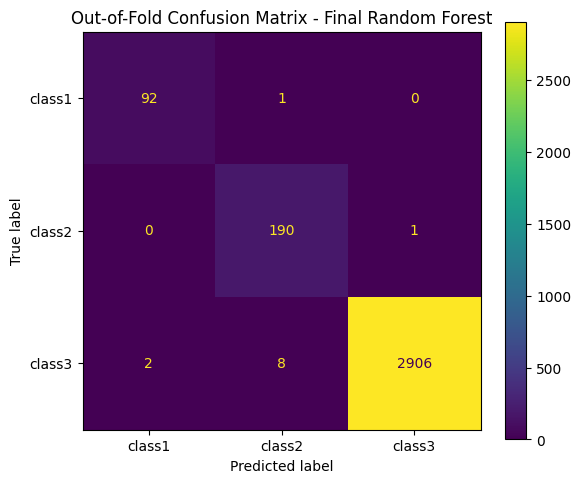

In [13]:
final_oof = oof_predictions_by_run[FINAL_RUN_NAME]
print(classification_report(y, final_oof, digits=4))

labels = sorted(y.unique())
cm = confusion_matrix(y, final_oof, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, values_format="d")
plt.title("Out-of-Fold Confusion Matrix - Final Random Forest")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "final_rf_oof_confusion_matrix.png", dpi=160)
plt.show()

report_dict = classification_report(y, final_oof, output_dict=True)
pd.DataFrame(report_dict).T.to_csv(REPORTS_DIR / "final_rf_oof_classification_report.csv")

## 15. Feature Importance

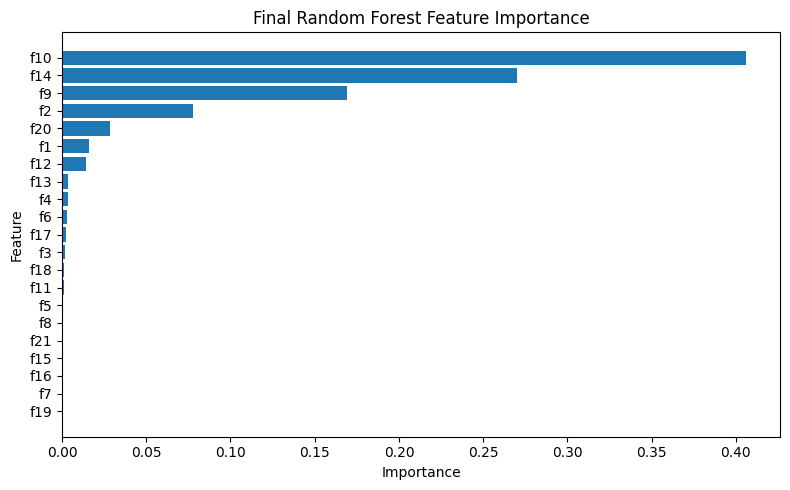

,feature,importance
9,f10,0.405887
13,f14,0.270061
8,f9,0.169064
1,f2,0.077805
19,f20,0.028421
0,f1,0.015898
11,f12,0.014157
12,f13,0.003764
3,f4,0.003342
5,f6,0.002906


In [14]:
rf_model = final_model.named_steps["model"]
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)
importance_df.to_csv(REPORTS_DIR / "final_rf_feature_importance.csv", index=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"].iloc[::-1], importance_df["importance"].iloc[::-1])
plt.title("Final Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "final_rf_feature_importance.png", dpi=160)
plt.show()

importance_df.head(10)

## 16. Generate Final Submission

The test set is used only for prediction after model selection is complete.

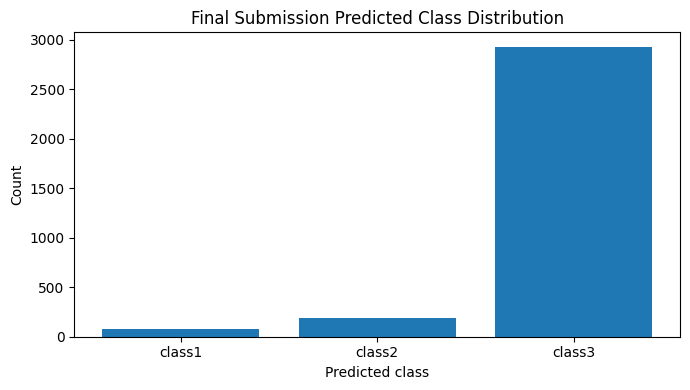

Final submission saved to: c:\Users\ASUS\Desktop\ML_2\results_required_mlops\submissions\FINAL_RECOMMENDED_submission_stable_random_forest_balanced_n500.csv


,target,count,percentage
0,class1,82,2.56250
1,class2,189,5.90625
2,class3,2929,91.53125


In [15]:
final_predictions = final_model.predict(X_test)
final_submission = pd.DataFrame({
    "ID": test_df["ID"],
    "target": final_predictions
})

# Match the required submission structure exactly.
assert list(final_submission.columns) == ["ID", "target"]
assert len(final_submission) == len(sample_submission)

final_submission_path = SUBMISSIONS_DIR / "FINAL_RECOMMENDED_submission_stable_random_forest_balanced_n500.csv"
final_submission.to_csv(final_submission_path, index=False)

pred_dist = final_submission["target"].value_counts().sort_index().rename_axis("target").reset_index(name="count")
pred_dist["percentage"] = 100 * pred_dist["count"] / len(final_submission)
pred_dist.to_csv(REPORTS_DIR / "final_submission_predicted_distribution.csv", index=False)

plt.figure(figsize=(7, 4))
plt.bar(pred_dist["target"], pred_dist["count"])
plt.title("Final Submission Predicted Class Distribution")
plt.xlabel("Predicted class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "final_submission_predicted_distribution.png", dpi=160)
plt.show()

print("Final submission saved to:", final_submission_path)
pred_dist

## 17. Log Final Model and Submission as MLflow Artifacts

The final run stores:

- final selected model parameters
- final validation metrics from the selected run
- trained pipeline artifact
- joblib backup
- final submission CSV

In [16]:
if mlflow is not None:
    selected_row = results_df[results_df["run_name"] == FINAL_RUN_NAME].iloc[0].to_dict()

    with mlflow.start_run(run_name="FINAL_selected_random_forest_pipeline"):
        mlflow.log_param("final_model_name", "RandomForestClassifier")
        mlflow.log_param("n_estimators", 500)
        mlflow.log_param("class_weight", "balanced")
        mlflow.log_param("selection_reason", "Best stability-adjusted validation performance among robust representative experiments")
        mlflow.log_param("selection_policy", "StratifiedKFold plus macro_f1 stability; not public leaderboard chasing")
        mlflow.log_param("preprocessing", "SimpleImputer median + RandomForestClassifier")

        for metric_name in [
            "accuracy_mean", "balanced_accuracy_mean", "macro_f1_mean", "macro_f1_std",
            "weighted_f1_mean", "train_valid_macro_f1_gap", "stability_adjusted_macro_f1"
        ]:
            mlflow.log_metric(metric_name, float(selected_row[metric_name]))

        mlflow.log_artifact(str(final_submission_path), artifact_path="submission")
        mlflow.log_artifact(str(final_joblib_path), artifact_path="joblib_model")
        mlflow.log_artifact(str(REPORTS_DIR / "required_experiment_results_with_decisions.csv"), artifact_path="reports")

        mlflow.sklearn.log_model(
            final_model,
            artifact_path="sklearn_pipeline",
            serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
        )

    print("Final model and submission logged to MLflow.")
else:
    print("MLflow not available; artifact logging skipped.")

2026/07/01 15:56:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Final model and submission logged to MLflow.


## 18. MLflow UI Instructions

Run this command from a terminal inside the project folder:

```cmd
mlflow ui --backend-store-uri sqlite:///C:/Users/ASUS/Desktop/ML_2/results_required_mlops/mlflow.db --default-artifact-root file:///C:/Users/ASUS/Desktop/ML_2/results_required_mlops/mlflow_artifacts --host 127.0.0.1 --port 5002
```

If your project path is different, use the command printed by the next cell.

In the MLflow UI, open the experiment:

```text
ML2_final_required_experiments
```

Recommended screenshot columns:

- Run Name
- `params.model_name`
- `params.scaler`
- `params.sampling`
- `params.class_weight`
- `params.n_estimators`
- `params.max_depth`
- `params.learning_rate`
- `metrics.accuracy_mean`
- `metrics.balanced_accuracy_mean`
- `metrics.macro_f1_mean`
- `metrics.weighted_f1_mean`
- `metrics.stability_adjusted_macro_f1`

This produces a clear comparison table with model inputs and evaluation outputs.

In [17]:
if mlflow is not None:
    db_uri = "sqlite:///" + (RESULTS_DIR / "mlflow.db").resolve().as_posix()
    artifact_uri = "file:///" + MLFLOW_ARTIFACTS_DIR.resolve().as_posix()
    print("Run this command in CMD or PowerShell:")
    print()
    print(f"mlflow ui --backend-store-uri {db_uri} --default-artifact-root {artifact_uri} --host 127.0.0.1 --port 5002")
    print()
    print("Then open: http://127.0.0.1:5002")
else:
    print("Install MLflow first: pip install mlflow")

Run this command in CMD or PowerShell:

mlflow ui --backend-store-uri sqlite:///C:/Users/ASUS/Desktop/ML_2/results_required_mlops/mlflow.db --default-artifact-root file:///C:/Users/ASUS/Desktop/ML_2/results_required_mlops/mlflow_artifacts --host 127.0.0.1 --port 5002

Then open: http://127.0.0.1:5002


## 19. Final Notes

This notebook avoids selecting a model only because it performs well on the public leaderboard. Public leaderboard feedback may be noisy or unrepresentative of the private leaderboard. The final model is selected because it has strong validation performance, low fold-to-fold variation, class-imbalance handling, and reproducibility through MLflow.